In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# List files in dataset folder
for dirname, _, filenames in os.walk('/kaggle/input/world-population-by-country-2026'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Load CSV
df = pd.read_csv("/kaggle/input/world-population-by-country-2026/world_population_by_country_2026.csv")

# Quick look at data
df.head()

/kaggle/input/world-population-by-country-2026/world_population_by_country_2026.csv


,Rank,Country,Population_2026,Yearly_Change,Net_Change,Density_per_km2,Land_Area_km2,Migrants_Net,Fertility_Rate,Median_Age,Urban_Population_pct,World_Share_pct
0,1,India,1476625576,0.87,12760051.0,497,2973190,-440456.0,1.93,29.2,37.6,17.79
1,2,China,1412914089,-0.22,-3182005.0,150,9388211,-232107.0,1.03,40.6,68.7,17.02
2,3,United States,349035494,0.51,1759687.0,38,9147420,1177848.0,1.63,38.7,83.1,4.20
3,4,Indonesia,287886782,0.76,2165546.0,159,1811570,-39472.0,2.08,30.7,60.3,3.47
4,5,Pakistan,259299791,1.60,4080237.0,336,770880,-1144738.0,3.44,20.8,34.7,3.12


In [2]:
# Info and summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Rank                  233 non-null    int64  
 1   Country               233 non-null    object 
 2   Population_2026       233 non-null    int64  
 3   Yearly_Change         233 non-null    float64
 4   Net_Change            233 non-null    float64
 5   Density_per_km2       233 non-null    int64  
 6   Land_Area_km2         233 non-null    int64  
 7   Migrants_Net          233 non-null    float64
 8   Fertility_Rate        233 non-null    float64
 9   Median_Age            233 non-null    float64
 10  Urban_Population_pct  233 non-null    float64
 11  World_Share_pct       233 non-null    float64
dtypes: float64(7), int64(4), object(1)
memory usage: 22.0+ KB


In [3]:
df.describe()

,Rank,Population_2026,Yearly_Change,Net_Change,Density_per_km2,Land_Area_km2,Migrants_Net,Fertility_Rate,Median_Age,Urban_Population_pct,World_Share_pct
count,233.000000,2.330000e+02,233.000000,2.330000e+02,233.000000,2.330000e+02,2.330000e+02,233.000000,233.000000,233.000000,233.000000
mean,117.000000,3.561725e+07,0.836009,2.964517e+05,489.090129,5.583427e+05,6.718884e+01,2.269957,32.067382,55.100000,0.429011
std,67.405489,1.397550e+08,1.204607,1.068382e+06,2408.108135,1.694270e+06,1.320280e+05,1.115550,10.105033,28.122878,1.683488
min,1.000000,5.060000e+02,-3.330000,-3.182005e+06,0.000000,0.000000e+00,-1.144738e+06,0.000000,0.000000,0.000000,0.000006
25%,59.000000,4.697750e+05,-0.050000,-4.700000e+01,39.000000,2.830000e+03,-7.971000e+03,1.470000,23.000000,35.500000,0.005700
50%,117.000000,5.853949e+06,0.770000,1.840600e+04,100.000000,8.220000e+04,-2.490000e+02,1.900000,33.300000,59.700000,0.071000
75%,175.000000,2.460170e+07,1.780000,2.286820e+05,255.000000,4.103400e+05,2.157000e+03,2.920000,40.200000,78.900000,0.300000
max,233.000000,1.476626e+09,3.370000,1.276005e+07,25562.000000,1.637687e+07,1.177848e+06,5.830000,56.200000,99.600000,17.790000


In [4]:
#Counts missing values
df.isnull().sum()  

Rank                    0
Country                 0
Population_2026         0
Yearly_Change           0
Net_Change              0
Density_per_km2         0
Land_Area_km2           0
Migrants_Net            0
Fertility_Rate          0
Median_Age              0
Urban_Population_pct    0
World_Share_pct         0
dtype: int64

## **Top 10 Most Populous Countries**

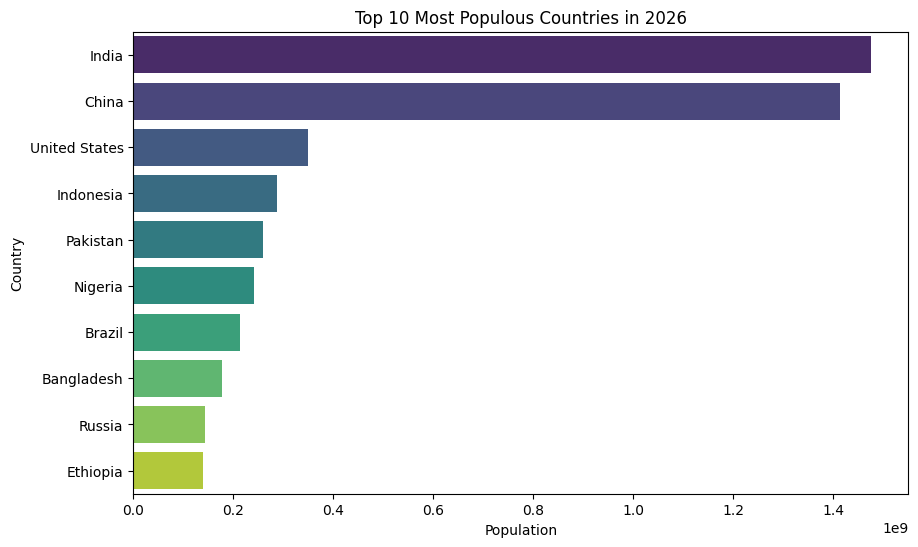

In [5]:
# Sort the dataframe by population descending and take the top 10
top10_pop = df.sort_values(by="Population_2026", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Population_2026", y="Country", data=top10_pop, hue="Country", dodge=False, palette="viridis")
plt.title("Top 10 Most Populous Countries in 2026")
plt.xlabel("Population")
plt.ylabel("Country")
plt.show()

# **Top 10 Countries by Population Density**

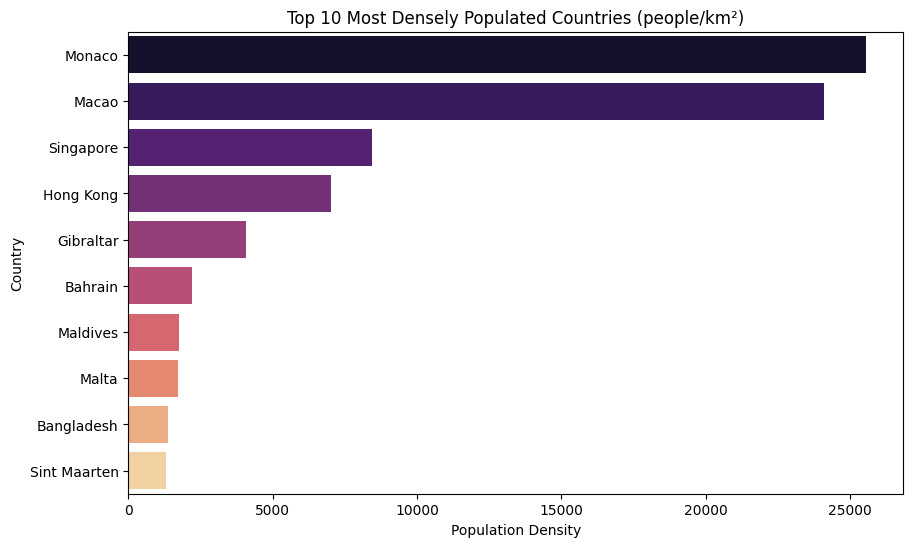

In [6]:
top10_density = df.sort_values("Density_per_km2", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Density_per_km2", y="Country", data=top10_density, hue="Country", dodge=False, palette="magma")
plt.title("Top 10 Most Densely Populated Countries (people/km²)")
plt.xlabel("Population Density")
plt.ylabel("Country")
plt.show()

## **Urbanization Analysis**

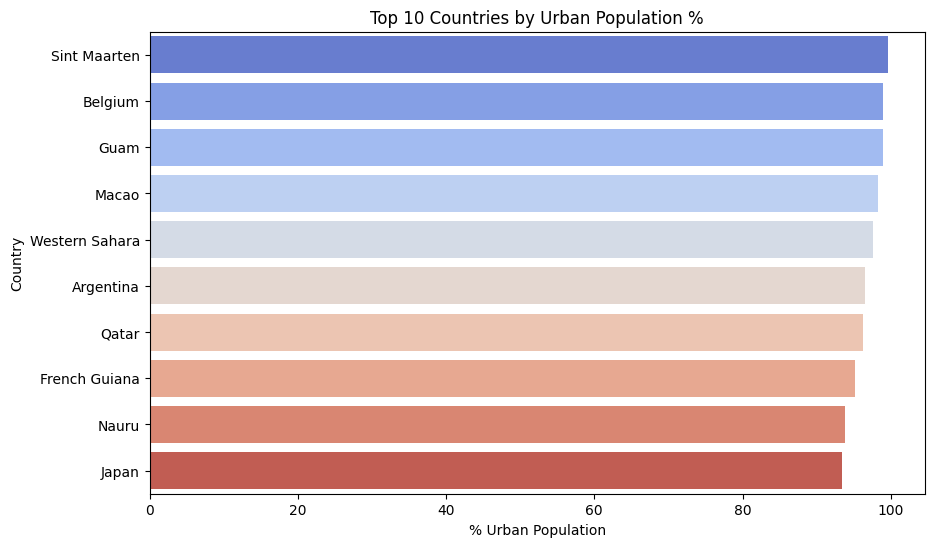

In [7]:
# Top 10 countries with the highest urban population %
top10_urban = df.sort_values("Urban_Population_pct", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Urban_Population_pct", y="Country", data=top10_urban, hue="Country", dodge=False, palette="coolwarm")
plt.title("Top 10 Countries by Urban Population %")
plt.xlabel("% Urban Population")
plt.ylabel("Country")
plt.show()

## **Fertility Rate vs Median Age**

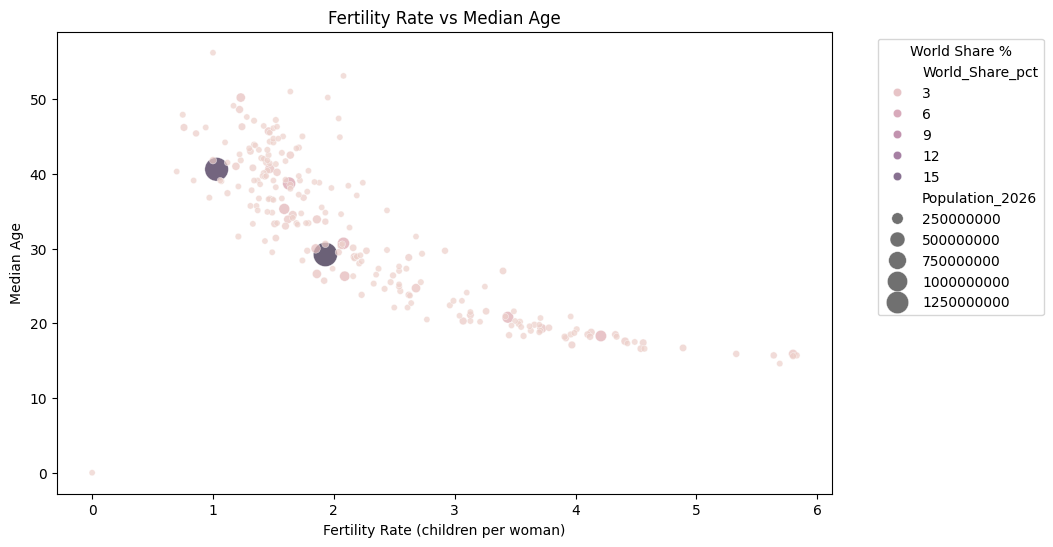

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="Fertility_Rate", y="Median_Age", data=df, hue="World_Share_pct", size="Population_2026", sizes=(20,300), alpha=0.7)
plt.title("Fertility Rate vs Median Age")
plt.xlabel("Fertility Rate (children per woman)")
plt.ylabel("Median Age")
plt.legend(title="World Share %", bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

## **World Share of Population**

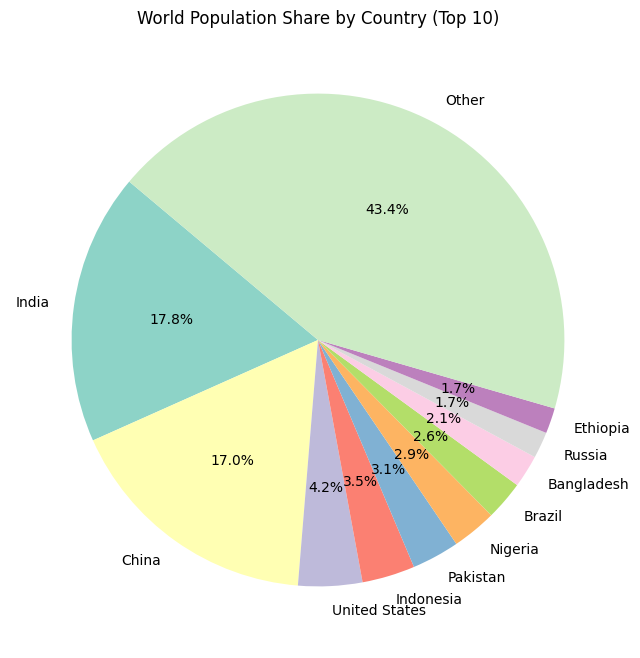

In [9]:
# Top 10 countries by world share
top10_world = df.sort_values("World_Share_pct", ascending=False).head(10)
other_share = 100 - top10_world["World_Share_pct"].sum()

# Pie chart
plt.figure(figsize=(8,8))
plt.pie(list(top10_world["World_Share_pct"]) + [other_share], 
        labels=list(top10_world["Country"]) + ["Other"], 
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3", 11))
plt.title("World Population Share by Country (Top 10)")
plt.show()

## **Quick Insights**

In [10]:
# Countries with the highest migration inflow/outflow
top_migration_in = df.sort_values("Migrants_Net", ascending=False).head(10)
top_migration_out = df.sort_values("Migrants_Net", ascending=True).head(10)

print("Top 10 Countries by Net Migration Inflow:")
print(top_migration_in[["Country", "Migrants_Net"]])

print("\nTop 10 Countries by Net Migration Outflow:")
print(top_migration_out[["Country", "Migrants_Net"]])

Top 10 Countries by Net Migration Inflow:
           Country  Migrants_Net
2    United States     1177848.0
21  United Kingdom      364099.0
8           Russia      324924.0
56           Syria      305822.0
37          Canada      291403.0
28           Sudan      252038.0
44        Malaysia      159001.0
18         Germany      158442.0
54       Australia      131706.0
23    South Africa      131684.0

Top 10 Countries by Net Migration Outflow:
        Country  Migrants_Net
4      Pakistan    -1144738.0
0         India     -440456.0
7    Bangladesh     -371398.0
51        Nepal     -292014.0
1         China     -232107.0
17       Turkey     -217896.0
6        Brazil     -205642.0
13  Philippines     -144275.0
29       Uganda     -121799.0
63         Chad     -112304.0
